# Emotion Recognition z tekstu — klasyczne ML, RNN, fine-tuning Transformerów i XAI

Cel: porównanie metod klasyfikacji emocji (anger, joy, sadness, fear) na zbalansowanym zbiorze Combined.

Modele:
- Klasyczne: SVM, Decision Tree, Naive Bayes (+ TF-IDF)
- Rekurencyjne: BiLSTM, BiGRU
- Transformery fine-tuned: BERT, RoBERTa, DistilBERT, DistilRoBERTa
- Gotowe z HF: Emotion RoBERTa, Emotion BERT, Emotion DistilRoBERTa

Ewaluacja na 3 zestawach danych: testowy split Combined + cały ISEAR + cały GoEmotions.

In [1]:
# Instalacja zależności (odkomentuj przy pierwszym uruchomieniu)
# !pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm joblib transformers accelerate evaluate torch torchtext captum lime

In [2]:
import os, re, json, math, random, warnings
from pathlib import Path
from collections import Counter, defaultdict
from typing import Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, balanced_accuracy_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_context('notebook')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'DEVICE: {DEVICE}  |  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB' if torch.cuda.is_available() else 'CPU mode')

DEVICE: cuda  |  VRAM: 8.6GB


In [3]:
# ===== KONFIGURACJA =====
# Zmieniaj te parametry aby dopasować do pamięci:
# samples_per_class: ile próbek NA KLASĘ (4 klasy) -> total = samples_per_class * 4
# max_features_tfidf: rozmiar słownika TF-IDF (mniej = mniej RAM)
# batch_size: dla RNN
# batch_size_tfm: dla transformerów (8-16 na 8GB VRAM)
# tfm_max_len: długość tokenów (krócej = mniej VRAM)
# use_fp16: True = mieszana precyzja (oszczędza VRAM)
# active_models: które modele trenować (listę stringów)

PROJECT_ROOT = Path('.')
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'
PLOTS_DIR = PROJECT_ROOT / 'plots'
REPORTS_DIR = PROJECT_ROOT / 'reports'
for d in [DATA_DIR, CHECKPOINT_DIR, PLOTS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # Ścieżki danych
    'combined_path': '../data/project_data/reduced/combined_red.csv',
    'isear_path': '../data/project_data/reduced/isear_red.csv',
    'goemotions_path': '../data/project_data/reduced/goemotions_red.csv',  # jeśli None, GoEmotions będzie pominięty w ewaluacji

    # Cele
    'target_emotions': ['anger', 'joy', 'sadness', 'fear'],

    # Balansowanie
    'samples_per_class': 15000,  # -> 60k total. Zmień na 5000-10000 jeśli brakuje RAM

    # TF-IDF dla klasycznych modeli
    'max_features_tfidf': 15000,
    'ngram_range': (1, 2),
    'min_df': 5,

    # RNN
    'max_seq_len_rnn': 80,
    'embed_dim': 128,
    'hidden_dim': 128,
    'batch_size': 32,
    'rnn_epochs': 10,
    'learning_rate_rnn': 2e-3,

    # Transformery
    'tfm_max_len': 64,
    'batch_size_tfm': 16,
    'transformer_epochs': 3,
    'learning_rate_transformer': 2e-5,
    'use_fp16': True,

    # Modele HF do fine-tuningu
    'hf_models_to_finetune': {
        'Own-DistilBERT': 'distilbert-base-uncased',
        'Own-DistilRoBERTa': 'distilroberta-base',
        'BERT': 'bert-base-uncased',
        'RoBERTa': 'roberta-base',
        'DeBERTaV3': 'microsoft/deberta-v3-base',
    },
    'pretrained_emotion_roberta': 'SamLowe/roberta-base-go_emotions',
    'pretrained_emotion_bert': 'bhadresh-savani/bert-base-uncased-emotion',
    'pretrained_emotion_deberta': 'hrshlgunjal/emotion-classifier-deberta-v3',

    # Które modele uruchomić (stringi)
    # 'SVM', 'DecisionTree', 'NaiveBayes', 'BiLSTM', 'BiGRU',
    # 'Own-DistilBERT', 'DistilRoBERTa', 'BERT', 'RoBERTa', 'Pretrained'
    'active_models': ['SVM', 'DecisionTree', 'NaiveBayes', 'BiLSTM', 'BiGRU',
                      'Own-DistilBERT', 'Own-DistilRoBERTa', 'DeBERTaV3', 'Pretrained'],

    # XAI
    'xai_n_examples': 30,
    'xai_top_k': 10,
}

print(json.dumps(CONFIG, indent=2, default=str))
total = CONFIG['samples_per_class'] * len(CONFIG['target_emotions'])
print(f'\nTotal samples po zbalansowaniu: ~{total}k ({CONFIG["samples_per_class"]} per class)')

{
  "combined_path": "../data/project_data/reduced/combined_red.csv",
  "isear_path": "../data/project_data/reduced/isear_red.csv",
  "goemotions_path": "../data/project_data/reduced/goemotions_red.csv",
  "target_emotions": [
    "anger",
    "joy",
    "sadness",
    "fear"
  ],
  "samples_per_class": 15000,
  "max_features_tfidf": 15000,
  "ngram_range": [
    1,
    2
  ],
  "min_df": 5,
  "max_seq_len_rnn": 80,
  "embed_dim": 128,
  "hidden_dim": 128,
  "batch_size": 32,
  "rnn_epochs": 10,
  "learning_rate_rnn": 0.002,
  "tfm_max_len": 64,
  "batch_size_tfm": 16,
  "transformer_epochs": 3,
  "learning_rate_transformer": 2e-05,
  "use_fp16": true,
  "hf_models_to_finetune": {
    "Own-DistilBERT": "distilbert-base-uncased",
    "Own-DistilRoBERTa": "distilroberta-base",
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "DeBERTaV3": "microsoft/deberta-v3-base"
  },
  "pretrained_emotion_roberta": "SamLowe/roberta-base-go_emotions",
  "pretrained_emotion_bert": "bh

## 1. Wczytywanie i balansowanie Combined datasetu

In [4]:
def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_combined(path, emotions, samples_per_class):
    df = pd.read_csv(path)
    # znajdź kolumny
    text_col = [c for c in df.columns if c.lower() in ('text','sentence','content')]
    label_col = [c for c in df.columns if c.lower() in ('emotion','label','sentiment')]
    if not text_col or not label_col:
        raise ValueError(f'Kolumny: {list(df.columns)}')
    out = pd.DataFrame({
        'text': df[text_col[0]].map(clean_text),
        'emotion': df[label_col[0]].str.strip().str.lower(),
    })
    out = out[out['emotion'].isin(emotions)]
    out = out.dropna(subset=['text', 'emotion'])
    out = out[out['text'].str.len() > 0].drop_duplicates(subset=['text'])
    # balansowanie: sample per class
    balanced = []
    for e in emotions:
        subset = out[out['emotion'] == e]
        if len(subset) >= samples_per_class:
            subset = subset.sample(samples_per_class, random_state=SEED)
        else:
            subset = subset.sample(frac=1, replace=True, random_state=SEED)[:samples_per_class]
        balanced.append(subset)
    result = pd.concat(balanced, ignore_index=True)
    return result.sample(frac=1, random_state=SEED).reset_index(drop=True)

def load_external(path, emotions, label='dataset_name'):
    if not path or not Path(path).exists():
        return None
    df = pd.read_csv(path)
    text_col = [c for c in df.columns if c.lower() in ('text','sentence','content')]
    label_col = [c for c in df.columns if c.lower() in ('emotion','label','sentiment')]
    if not text_col or not label_col:
        return None
    out = pd.DataFrame({
        'text': df[text_col[0]].map(clean_text),
        'emotion': df[label_col[0]].str.strip().str.lower(),
    })
    out = out[out['emotion'].isin(emotions)]
    out = out.dropna(subset=['text', 'emotion'])
    out = out[out['text'].str.len() > 0].drop_duplicates(subset=['text'])
    return out.reset_index(drop=True)

print('Ładowanie Combined...')
combined = load_combined(CONFIG['combined_path'], CONFIG['target_emotions'], CONFIG['samples_per_class'])
print(f'Combined zbalansowany: {len(combined)} próbek')
print(combined['emotion'].value_counts())

print('\nŁadowanie ISEAR...')
isear = load_external(CONFIG['isear_path'], CONFIG['target_emotions'])
if isear is not None:
    print(f'ISEAR: {len(isear)} próbek')
    print(isear['emotion'].value_counts())

print('\nŁadowanie GoEmotions...')
goemotions = load_external(CONFIG['goemotions_path'], CONFIG['target_emotions'])
if goemotions is not None:
    print(f'GoEmotions: {len(goemotions)} próbek')
    print(goemotions['emotion'].value_counts())

Ładowanie Combined...
Combined zbalansowany: 60000 próbek
emotion
anger      15000
sadness    15000
fear       15000
joy        15000
Name: count, dtype: int64

Ładowanie ISEAR...
ISEAR: 4284 próbek
emotion
joy        1080
anger      1078
fear       1072
sadness    1054
Name: count, dtype: int64

Ładowanie GoEmotions...
GoEmotions: 11092 próbek
emotion
anger      3833
joy        3317
sadness    2757
fear       1185
Name: count, dtype: int64


In [5]:
# Podział Combined na train/val/test
label_encoder = LabelEncoder()
combined['label'] = label_encoder.fit_transform(combined['emotion'])
label_names = list(label_encoder.classes_)
num_labels = len(label_names)
print('Klasy:', label_names)

train_df, temp_df = train_test_split(
    combined, test_size=0.3, stratify=combined['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED
)

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print(f'\nTest set label distribution:')
print(test_df['emotion'].value_counts())

# Przygotuj zewnętrzne zbiory testowe
def prepare_test_set(df, name):
    if df is None or len(df) == 0:
        return None
    df = df.copy()
    df['label'] = df['emotion'].map({l: i for i, l in enumerate(label_names)})
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
    print(f'{name}: {len(df)} próbek')
    return df

isear_test = prepare_test_set(isear, 'ISEAR')
goemotions_test = prepare_test_set(goemotions, 'GoEmotions')

joblib.dump(label_encoder, CHECKPOINT_DIR / 'label_encoder.joblib')

Klasy: ['anger', 'fear', 'joy', 'sadness']
Train: 42000, Val: 9000, Test: 9000

Test set label distribution:
emotion
anger      2250
sadness    2250
fear       2250
joy        2250
Name: count, dtype: int64
ISEAR: 4284 próbek
GoEmotions: 11092 próbek


['checkpoints/label_encoder.joblib']

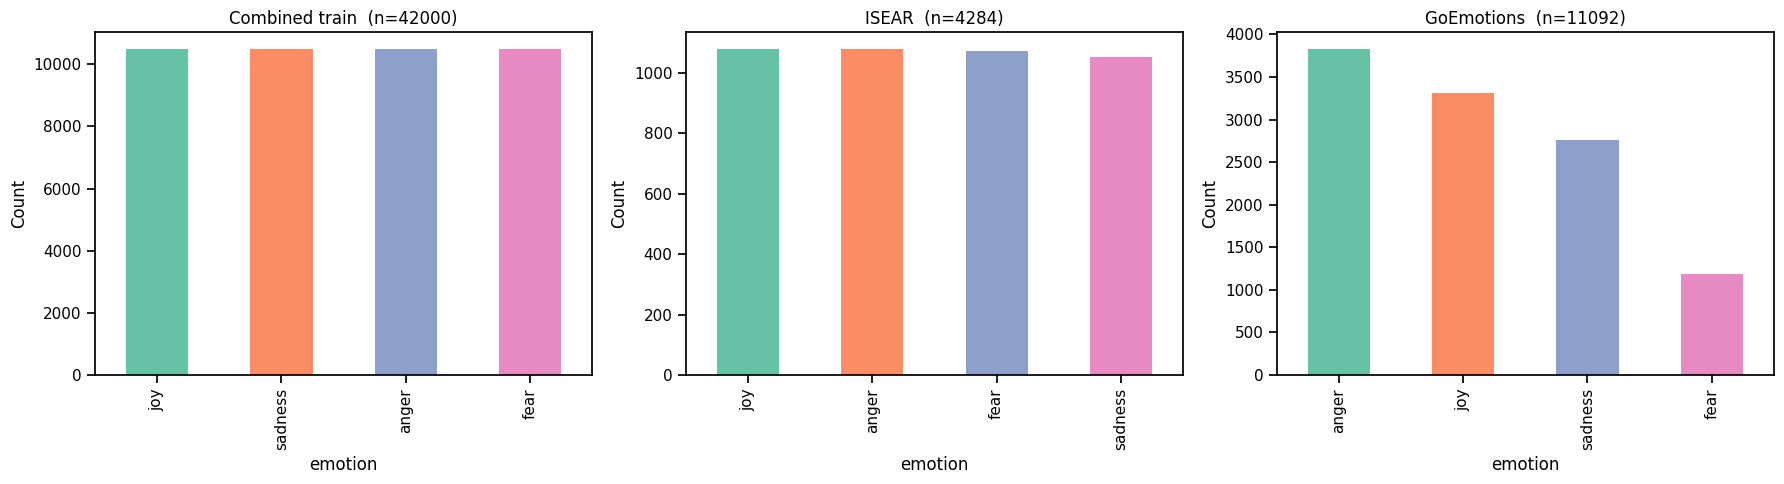

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, df) in zip(axes, [('Combined train', train_df), ('ISEAR', isear_test), ('GoEmotions', goemotions_test)]):
    if df is not None:
        df['emotion'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
        ax.set_title(f'{name}  (n={len(df)})')
        ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'dataset_distributions.png', dpi=150)
plt.show()

## 2. Funkcje ewaluacji — wspólne dla wszystkich modeli

In [7]:
all_results = []  # lista słowników z metrykami per (model, dataset)
all_predictions = defaultdict(dict)  # model -> dataset -> {'y_true', 'y_pred', 'y_proba'}

# Zbiory ewaluacyjne
EVAL_SETS = {
    'Combined_test': test_df,
}
if isear_test is not None:
    EVAL_SETS['ISEAR'] = isear_test
if goemotions_test is not None:
    EVAL_SETS['GoEmotions'] = goemotions_test

def evaluate_model(model_name: str, predict_fn, dataset_name: str, df):
    y_true = df['label'].values
    y_pred, y_proba = predict_fn(df['text'].tolist())
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    w_prec, w_rec, w_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    result = {
        'model': model_name,
        'dataset': dataset_name,
        'accuracy': acc,
        'balanced_accuracy': bacc,
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'weighted_f1': w_f1,
    }
    all_results.append(result)
    all_predictions[model_name][dataset_name] = {'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba}
    return result

def eval_on_all_sets(model_name, predict_fn):
    print(f'\n=== {model_name} ===')
    for ds_name, ds_df in EVAL_SETS.items():
        res = evaluate_model(model_name, predict_fn, ds_name, ds_df)
        print(f'  {ds_name:20s}  acc={res["accuracy"]:.4f}  macro_f1={res["macro_f1"]:.4f}  w_f1={res["weighted_f1"]:.4f}')

def print_classification_report(model_name, dataset_name):
    d = all_predictions[model_name][dataset_name]
    print(classification_report(d['y_true'], d['y_pred'], target_names=label_names, zero_division=0))

def plot_confusion(model_name, dataset_name):
    d = all_predictions[model_name][dataset_name]
    cm = confusion_matrix(d['y_true'], d['y_pred'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title(f'{model_name} — {dataset_name}')
    plt.xlabel('Prediction'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'confusion_{model_name}_{dataset_name}.png', dpi=150)
    plt.show()

## 3. Klasyczne ML: SVM, Decision Tree, Naive Bayes

In [8]:
def train_classic_model(name, clf):
    path = CHECKPOINT_DIR / f'{name}.joblib'
    if path.exists():
        print(f'Loading {name} from {path}...')
        pipe = joblib.load(path)
    else:
        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=CONFIG['max_features_tfidf'],
                ngram_range=CONFIG['ngram_range'],
                min_df=CONFIG['min_df']
            )),
            ('clf', clf)
        ])
        print(f'Training {name} on {len(train_df)} samples...')
        pipe.fit(train_df['text'].values, train_df['label'].values)
        joblib.dump(pipe, path)

    def predict_fn(texts):
        preds = pipe.predict(texts)
        if hasattr(pipe, 'predict_proba'):
            proba = pipe.predict_proba(texts)
        else:
            proba = None
        return preds, proba
    return predict_fn

classic_fns = {}
if 'SVM' in CONFIG['active_models']:
    classic_fns['SVM'] = train_classic_model('SVM', LinearSVC(class_weight='balanced', random_state=SEED, max_iter=2000))
if 'DecisionTree' in CONFIG['active_models']:
    classic_fns['DecisionTree'] = train_classic_model('DecisionTree', DecisionTreeClassifier(max_depth=50, min_samples_split=10, class_weight='balanced', random_state=SEED))
if 'NaiveBayes' in CONFIG['active_models']:
    classic_fns['NaiveBayes'] = train_classic_model('NaiveBayes', MultinomialNB())

for name, fn in classic_fns.items():
    eval_on_all_sets(name, fn)

Loading SVM from checkpoints/SVM.joblib...
Loading DecisionTree from checkpoints/DecisionTree.joblib...
Loading NaiveBayes from checkpoints/NaiveBayes.joblib...

=== SVM ===
  Combined_test         acc=0.9513  macro_f1=0.9513  w_f1=0.9513
  ISEAR                 acc=0.6123  macro_f1=0.6132  w_f1=0.6134
  GoEmotions            acc=0.4516  macro_f1=0.4156  w_f1=0.4443

=== DecisionTree ===
  Combined_test         acc=0.5691  macro_f1=0.5157  w_f1=0.5157
  ISEAR                 acc=0.3567  macro_f1=0.2839  w_f1=0.2855
  GoEmotions            acc=0.3250  macro_f1=0.1980  w_f1=0.1921

=== NaiveBayes ===
  Combined_test         acc=0.9138  macro_f1=0.9138  w_f1=0.9138
  ISEAR                 acc=0.6020  macro_f1=0.5998  w_f1=0.6002
  GoEmotions            acc=0.4902  macro_f1=0.4563  w_f1=0.4879


## 4. RNN: BiLSTM i BiGRU

In [9]:
class TextVocab:
    def __init__(self, max_size=30000, min_freq=2):
        self.max_size = max_size
        self.min_freq = min_freq
        self.stoi = {'<pad>': 0, '<unk>': 1}
        self.itos = ['<pad>', '<unk>']

    def tokenize(self, text):
        return re.findall(r"\b\w+\b|[^\w\s]", str(text).lower())

    def fit(self, texts):
        counter = Counter()
        for t in texts:
            counter.update(self.tokenize(t))
        for tok, freq in counter.most_common(self.max_size - 2):
            if freq >= self.min_freq:
                self.stoi[tok] = len(self.itos)
                self.itos.append(tok)
        return self

    def encode(self, text, max_len):
        ids = [self.stoi.get(tok, 1) for tok in self.tokenize(text)[:max_len]]
        ids += [0] * (max_len - len(ids))
        return ids

class RNNDataset(Dataset):
    def __init__(self, df, vocab, max_len):
        self.texts = df['text'].tolist()
        self.labels = df['label'].values.astype(np.int64)
        self.vocab = vocab
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.vocab.encode(self.texts[idx], self.max_len), dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels, rnn_type='lstm', dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn = rnn_cls(embed_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)
    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        out, _ = self.rnn(emb)
        mask = (input_ids != 0).unsqueeze(-1)
        out = out.masked_fill(~mask, 0.0)
        pooled = out.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.fc(self.dropout(pooled))

@torch.no_grad()
def predict_rnn(model, loader):
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    for batch in loader:
        ids = batch['input_ids'].to(DEVICE)
        labels = batch['label'].cpu().numpy()
        logits = model(ids)
        proba = torch.softmax(logits, dim=-1).cpu().numpy()
        pred = proba.argmax(axis=1)
        y_true.extend(labels); y_pred.extend(pred); y_proba.extend(proba)
    return np.array(y_true), np.array(y_pred), np.array(y_proba)

def train_rnn(model_name, rnn_type):
    ckpt_path = CHECKPOINT_DIR / f'{model_name}.pt'
    if ckpt_path.exists():
        print(f'Loading {model_name} from {ckpt_path}...')
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        vocab = ckpt['vocab']
        model = BiRNNClassifier(len(vocab.itos), CONFIG['embed_dim'], CONFIG['hidden_dim'], num_labels, rnn_type=rnn_type).to(DEVICE)
        model.load_state_dict(ckpt['model_state'])
    else:
        vocab = TextVocab(max_size=30000, min_freq=2).fit(train_df['text'])
        train_ds = RNNDataset(train_df, vocab, CONFIG['max_seq_len_rnn'])
        val_ds = RNNDataset(val_df, vocab, CONFIG['max_seq_len_rnn'])
        train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], num_workers=0)

        model = BiRNNClassifier(len(vocab.itos), CONFIG['embed_dim'], CONFIG['hidden_dim'], num_labels, rnn_type=rnn_type).to(DEVICE)
        optim = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate_rnn'])
        criterion = nn.CrossEntropyLoss()
        best_val_f1 = -1
        train_losses = []

        for epoch in range(CONFIG['rnn_epochs']):
            model.train()
            losses = []
            for batch in tqdm(train_loader, desc=f'{model_name} ep.{epoch+1}'):
                ids = batch['input_ids'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                optim.zero_grad()
                logits = model(ids)
                loss = criterion(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
                losses.append(loss.item())
            train_losses.append(np.mean(losses))

            y_val, p_val, _ = predict_rnn(model, val_loader)
            f1 = precision_recall_fscore_support(y_val, p_val, average='macro', zero_division=0)[2]
            print(f'{model_name} ep.{epoch+1}  loss={np.mean(losses):.4f}  val_macro_f1={f1:.4f}')
            if f1 > best_val_f1:
                best_val_f1 = f1
                torch.save({'model_state': model.state_dict(), 'vocab': vocab, 'epoch': epoch}, ckpt_path)

        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state'])

    def predict_fn(texts):
        ds = RNNDataset(pd.DataFrame({'text': texts, 'label': [0]*len(texts)}), vocab, CONFIG['max_seq_len_rnn'])
        loader = DataLoader(ds, batch_size=CONFIG['batch_size'], num_workers=0)
        _, y_pred, y_proba = predict_rnn(model, loader)
        return y_pred, y_proba
    return predict_fn

rnn_fns = {}
if 'BiLSTM' in CONFIG['active_models']:
    rnn_fns['BiLSTM'] = train_rnn('BiLSTM', 'lstm')
if 'BiGRU' in CONFIG['active_models']:
    rnn_fns['BiGRU'] = train_rnn('BiGRU', 'gru')

for name, fn in rnn_fns.items():
    eval_on_all_sets(name, fn)

Loading BiLSTM from checkpoints/BiLSTM.pt...
Loading BiGRU from checkpoints/BiGRU.pt...

=== BiLSTM ===
  Combined_test         acc=0.9766  macro_f1=0.9766  w_f1=0.9766
  ISEAR                 acc=0.4339  macro_f1=0.4065  w_f1=0.4069
  GoEmotions            acc=0.4370  macro_f1=0.3714  w_f1=0.4013

=== BiGRU ===
  Combined_test         acc=0.9758  macro_f1=0.9758  w_f1=0.9758
  ISEAR                 acc=0.5387  macro_f1=0.5230  w_f1=0.5232
  GoEmotions            acc=0.4245  macro_f1=0.3750  w_f1=0.3974


## 5. Fine-tuning Transformerów

In [11]:
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
    import evaluate
    HF_AVAILABLE = True
except Exception as e:
    HF_AVAILABLE = False
    print('Transformers/evaluate niedostępne:', e)

class HFDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        item = self.tokenizer(self.texts[idx], truncation=True, max_length=self.max_length, padding=False)
        item['labels'] = self.labels[idx]
        return item

def compute_metrics_hf(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(labels, preds), 'macro_precision': p, 'macro_recall': r, 'macro_f1': f1}

hf_predict_fns = {}

if HF_AVAILABLE:
    for alias, model_name in CONFIG['hf_models_to_finetune'].items():
        if alias not in CONFIG['active_models']:
            continue
        out_dir = CHECKPOINT_DIR / f'hf_{alias}'
        best_path = out_dir / 'best'
        if not best_path.exists() and "Own-" in alias:
            old_name = alias.replace("Own-", "")
            old_dir = CHECKPOINT_DIR / ("hf_" + old_name) / "best"
            if old_dir.exists():
                best_path = old_dir
        if best_path.exists() and (best_path / 'config.json').exists():
            print(f'Loading {alias} from {best_path}...')
            tokenizer = AutoTokenizer.from_pretrained(str(best_path))
            model = AutoModelForSequenceClassification.from_pretrained(str(best_path)).to(DEVICE)
            if alias == 'DeBERTaV3':
                model = model.float()
        else:
            print(f'\n===== Fine-tuning {alias} ({model_name}) =====')
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token else '[PAD]'

            model = AutoModelForSequenceClassification.from_pretrained(
                model_name, num_labels=num_labels,
                id2label={i: l for i, l in enumerate(label_names)},
                label2id={l: i for i, l in enumerate(label_names)},
            )
            try:
                model.gradient_checkpointing_enable()
            except:
                pass

            train_ds = HFDataset(train_df, tokenizer, CONFIG['tfm_max_len'])
            val_ds = HFDataset(val_df, tokenizer, CONFIG['tfm_max_len'])

            args = TrainingArguments(
                output_dir=str(out_dir),
                eval_strategy='epoch',
                save_strategy='epoch',
                learning_rate=CONFIG['learning_rate_transformer'],
                per_device_train_batch_size=CONFIG['batch_size_tfm'],
                per_device_eval_batch_size=CONFIG['batch_size_tfm'] * 2,
                num_train_epochs=CONFIG['transformer_epochs'],
                weight_decay=0.01,
                load_best_model_at_end=True,
                metric_for_best_model='macro_f1',
                greater_is_better=True,
                logging_steps=50,
                report_to='none',
                seed=SEED,
                fp16=CONFIG['use_fp16'] and alias != 'DeBERTaV3',
                dataloader_num_workers=0,
                save_total_limit=1,
            )
            trainer = Trainer(
                model=model, args=args,
                train_dataset=train_ds, eval_dataset=val_ds,
                data_collator=DataCollatorWithPadding(tokenizer),
                compute_metrics=compute_metrics_hf,
            )
            trainer.train()
            trainer.save_model(str(best_path))
            tokenizer.save_pretrained(str(best_path))

        def make_predict_fn(model, tokenizer):
            collator = DataCollatorWithPadding(tokenizer)
            def predict_fn(texts):
                ds = HFDataset(pd.DataFrame({'text': texts, 'label': [0]*len(texts)}), tokenizer, CONFIG['tfm_max_len'])
                model.eval()
                loader = DataLoader(ds, batch_size=CONFIG['batch_size_tfm'] * 2, collate_fn=collator, num_workers=0)
                all_logits = []
                with torch.no_grad():
                    for batch in loader:
                        inputs = {k: v.to(model.device) for k, v in batch.items() if k != 'labels'}
                        logits = model(**inputs).logits
                        all_logits.append(logits.cpu())
                y_proba = torch.softmax(torch.cat(all_logits), dim=-1).numpy()
                y_pred = y_proba.argmax(axis=1)
                return y_pred, y_proba
            return predict_fn

        hf_predict_fns[alias] = make_predict_fn(model, tokenizer)

for name, fn in hf_predict_fns.items():
    eval_on_all_sets(name, fn)

Loading Own-DistilBERT from checkpoints/hf_DistilBERT/best...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading Own-DistilRoBERTa from checkpoints/hf_DistilRoBERTa/best...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


===== Fine-tuning DeBERTaV3 (microsoft/deberta-v3-base) =====


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## 6. Gotowe modele z HF: Emotion RoBERTa, Emotion BERT, Emotion DistilRoBERTa


In [ ]:
if 'Pretrained' in CONFIG['active_models'] and HF_AVAILABLE:
    from transformers import pipeline

    pretrained_models = {
        'Emotion-RoBERTa': CONFIG['pretrained_emotion_roberta'],
        'Emotion-BERT': CONFIG['pretrained_emotion_bert'],
        'Emotion-DeBERTaV3': CONFIG['pretrained_emotion_deberta'],
    }

    for pname, pmodel in pretrained_models.items():
        print(f'\nLoading pretrained: {pname} ({pmodel})...')
        try:
            clf = pipeline('text-classification', model=pmodel, top_k=None, device=0 if DEVICE == 'cuda' else -1)

            def predict_pretrained(texts, pipe=clf):
                preds, probas = [], []
                for text in tqdm(texts, desc=pname):
                    outputs = pipe(text)[0]
                    scores = np.zeros(num_labels, dtype=float)
                    has_any = False
                    for o in outputs:
                        lab = o['label'].strip().lower()
                        if lab in label_names:
                            scores[label_names.index(lab)] += float(o['score'])
                            has_any = True
                    if not has_any:
                        # map if needed
                        for o in outputs:
                            lab = o['label'].strip().lower()
                            # Common label mappings
                            mapping = {
                                'anger': 'anger', 'angry': 'anger',
                                'joy': 'joy', 'happy': 'joy', 'happiness': 'joy',
                                'sadness': 'sadness', 'sad': 'sadness',
                                'fear': 'fear', 'frightened': 'fear', 'scared': 'fear',
                            }
                            mapped = mapping.get(lab)
                            if mapped and mapped in label_names:
                                scores[label_names.index(mapped)] += float(o['score'])
                                has_any = True
                    if not has_any:
                        scores[0] = 1.0
                    else:
                        scores /= scores.sum()
                    probas.append(scores)
                    preds.append(scores.argmax())
                return np.array(preds), np.array(probas)

            eval_on_all_sets(pname, predict_pretrained)
        except Exception as e:
            print(f'  Failed to load {pname}: {e}')


## 7. Porównanie wszystkich modeli na wszystkich datasetach

In [ ]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(REPORTS_DIR / 'all_results.csv', index=False)

print('\n===== WYNIKI ====')
pivot_f1 = results_df.pivot_table(index='model', columns='dataset', values='macro_f1', aggfunc='first')
print(pivot_f1.round(4).to_string())

In [ ]:
if len(results_df) > 0:
    metrics = ['accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']

    # 1. Grouped bar: models x datasets
    fig, axes = plt.subplots(1, len(EVAL_SETS), figsize=(6*len(EVAL_SETS), 5))
    if len(EVAL_SETS) == 1:
        axes = [axes]
    for ax, (ds_name, _) in zip(axes, EVAL_SETS.items()):
        sub = results_df[results_df['dataset'] == ds_name].sort_values('macro_f1', ascending=False)
        x = np.arange(len(sub))
        w = 0.2
        for i, m in enumerate(metrics):
            ax.bar(x + i*w - 1.5*w, sub[m].values, w, label=m)
        ax.set_xticks(x)
        ax.set_xticklabels(sub['model'].values, rotation=45, ha='right')
        ax.set_title(f'{ds_name} — macro F1', fontweight='bold')
        ax.legend(loc='lower right')
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'comparison_grouped.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Radar chart
    from math import pi
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    models_in_plot = results_df['model'].unique()
    datasets_in_plot = list(EVAL_SETS.keys())
    angles = [n / len(datasets_in_plot) * 2 * pi for n in range(len(datasets_in_plot))]
    angles += angles[:1]
    for model_name in models_in_plot:
        vals = []
        for ds in datasets_in_plot:
            row = results_df[(results_df['model'] == model_name) & (results_df['dataset'] == ds)]
            vals.append(row['macro_f1'].values[0] if len(row) > 0 else 0)
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', label=model_name)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(datasets_in_plot)
    ax.set_ylim(0, 1.05)
    ax.set_title('Macro F1 per dataset (radar)', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'comparison_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 3. Heatmap model x dataset
    pivot = results_df.pivot_table(index='model', columns='dataset', values='macro_f1', aggfunc='first')
    plt.figure(figsize=(10, max(5, len(pivot)*0.5)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1, cbar_kws={'label': 'Macro F1'})
    plt.title('Macro F1 — model × dataset', fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'comparison_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 4. Per-class accuracy per dataset (best model)
    best_model = results_df.groupby('model')['macro_f1'].mean().idxmax()
    print(f'\n=== Best overall model (avg macro_f1): {best_model} ===')
    for ds_name, ds_df in EVAL_SETS.items():
        d = all_predictions[best_model][ds_name]
        cr = classification_report(d['y_true'], d['y_pred'], target_names=label_names, zero_division=0, output_dict=True)
        per_class = pd.DataFrame(cr).T
        print(f'\n{best_model} — {ds_name}:')
        print(per_class[['precision', 'recall', 'f1-score']].drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore').round(4))

In [ ]:
# Confusion matrices grid: rows = models, columns = datasets
model_order = results_df.groupby('model')['macro_f1'].mean().sort_values(ascending=True).index
ds_order = list(EVAL_SETS.keys())
fig, axes = plt.subplots(len(model_order), len(ds_order), figsize=(5*len(ds_order), 4*len(model_order)), squeeze=False)
for i, model_name in enumerate(model_order):
    for j, ds_name in enumerate(ds_order):
        ax = axes[i, j]
        d = all_predictions[model_name][ds_name]
        cm = confusion_matrix(d['y_true'], d['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names, ax=ax, cbar=False)
        ax.set_title(f'{model_name} — {ds_name}', fontsize=9)
        ax.set_xlabel('Pred')
        ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrix_grid.png', dpi=150)
plt.show()

In [ ]:
# Training curves dla transformerów (z logów)
log_files = list(CHECKPOINT_DIR.glob('hf_*/trainer_state.json'))
if log_files:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for log_f in log_files:
        with open(log_f) as f:
            state = json.load(f)
        logs = state.get('log_history', [])
        name = log_f.parent.name.replace('hf_', '')
        train_loss = [l['loss'] for l in logs if 'loss' in l]
        eval_f1 = [l['eval_macro_f1'] for l in logs if 'eval_macro_f1' in l]
        if train_loss:
            axes[0].plot(train_loss, label=name)
        if eval_f1:
            axes[1].plot(eval_f1, label=name, marker='o')
    axes[0].set_title('Training loss')
    axes[0].legend(); axes[1].legend()
    axes[1].set_title('Validation macro F1')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'training_curves.png', dpi=150)
    plt.show()

## 8. XAI — wyjaśnienia

In [ ]:
xai_explanations = defaultdict(dict)

sample_xai_df = test_df.sample(min(CONFIG['xai_n_examples'], len(test_df)), random_state=SEED).reset_index(drop=True)

def normalize_attr_dict(d):
    total = sum(abs(v) for v in d.values())
    if total == 0: return d
    return {k: float(v) / total for k, v in d.items()}

def top_tokens_plot(model_name, attr_dict, suffix, top_k=15):
    items = sorted(attr_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:top_k]
    if not items: return
    toks, vals = zip(*items)
    plt.figure(figsize=(9, max(4, 0.35*len(toks))))
    sns.barplot(x=list(vals), y=list(toks), orient='h', palette='coolwarm')
    plt.title(f'XAI tokens — {model_name}')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'xai_{model_name}_{suffix}.png', dpi=150)
    plt.show()

# --- LIME dla modeli klasycznych ---
try:
    from lime.lime_text import LimeTextExplainer
    LIME_AVAILABLE = True
except:
    LIME_AVAILABLE = False

if LIME_AVAILABLE and len(classic_fns) > 0:
    explainer = LimeTextExplainer(class_names=label_names)
    for name, predict_fn in classic_fns.items():
        # sprawdź czy model wspiera predict_proba
        _, proba_check = predict_fn([sample_xai_df.iloc[0]['text']])
        if proba_check is None:
            print(f'  LIME skipped for {name} (no predict_proba)')
            continue
        def make_proba_fn(pfn):
            def proba_fn(texts):
                _, p = pfn(texts)
                return p
            return proba_fn
        pfn = make_proba_fn(predict_fn)
        for i, row in tqdm(sample_xai_df.iterrows(), total=len(sample_xai_df), desc=f'LIME {name}'):
            exp = explainer.explain_instance(row['text'], pfn, num_features=CONFIG['xai_top_k'], top_labels=1)
            pred_label = int(predict_fn([row['text']])[0][0])
            attr = dict(exp.as_list(label=pred_label))
            xai_explanations[f'LIME_{name}'][i] = normalize_attr_dict(attr)
        if len(sample_xai_df):
            top_tokens_plot(f'LIME_{name}', xai_explanations[f'LIME_{name}'][0], 'sample0')

# --- Integrated Gradients dla RNN ---
try:
    from captum.attr import LayerIntegratedGradients
    CAPTUM_AVAILABLE = True
except:
    CAPTUM_AVAILABLE = False

if CAPTUM_AVAILABLE:
    for name, predict_fn in rnn_fns.items():
        ckpt = torch.load(CHECKPOINT_DIR / f'{name}.pt', map_location=DEVICE, weights_only=False)
        vocab = ckpt['vocab']
        model = BiRNNClassifier(len(vocab.itos), CONFIG['embed_dim'], CONFIG['hidden_dim'], num_labels, rnn_type='lstm' if 'LSTM' in name else 'gru').to(DEVICE)
        model.load_state_dict(ckpt['model_state'])
        model.eval()

        for i, row in tqdm(sample_xai_df.iterrows(), total=len(sample_xai_df), desc=f'IG {name}'):
            ids = torch.tensor([vocab.encode(row['text'], CONFIG['max_seq_len_rnn'])], dtype=torch.long).to(DEVICE)
            tokens = [vocab.itos[j] if j < len(vocab.itos) else '<unk>' for j in ids[0].cpu().numpy()]
            lig = LayerIntegratedGradients(lambda x: model(x), model.embedding)
            baseline = torch.zeros_like(ids).to(DEVICE)
            model.train()
            attributions, _ = lig.attribute(ids, baselines=baseline, target=int(row['label']), return_convergence_delta=True)
            model.eval()
            scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
            attr = defaultdict(float)
            for tok, score in zip(tokens, scores):
                if tok not in ['<pad>', '<unk>']:
                    attr[tok] += float(score)
            xai_explanations[f'IG_{name}'][i] = normalize_attr_dict(dict(attr))
        if len(sample_xai_df):
            top_tokens_plot(f'IG_{name}', xai_explanations[f'IG_{name}'][0], 'sample0')

# --- LIME dla transformerów ---
if LIME_AVAILABLE and len(hf_predict_fns) > 0:
    explainer = LimeTextExplainer(class_names=label_names)
    for name, predict_fn in hf_predict_fns.items():
        def make_proba_fn(pfn):
            def proba_fn(texts):
                _, p = pfn(texts)
                return p
            return proba_fn
        pfn = make_proba_fn(predict_fn)
        for i, row in tqdm(sample_xai_df.iterrows(), total=len(sample_xai_df), desc=f'LIME {name}'):
            exp = explainer.explain_instance(row['text'], pfn, num_features=CONFIG['xai_top_k'], top_labels=1)
            pred_label = int(predict_fn([row['text']])[0][0])
            xai_explanations[f'LIME_{name}'][i] = normalize_attr_dict(dict(exp.as_list(label=pred_label)))
        if len(sample_xai_df):
            top_tokens_plot(f'LIME_{name}', xai_explanations[f'LIME_{name}'][0], 'sample0')

# --- Similarity XAI ---
if len(xai_explanations) > 1:
    from sklearn.metrics.pairwise import cosine_similarity
    from scipy.stats import spearmanr

    def jaccard_top_k(a, b, k=10):
        ta = set(x for x, _ in sorted(a.items(), key=lambda z: abs(z[1]), reverse=True)[:k])
        tb = set(x for x, _ in sorted(b.items(), key=lambda z: abs(z[1]), reverse=True)[:k])
        if not ta and not tb: return np.nan
        return len(ta & tb) / len(ta | tb)

    def attr_sim(a, b, k=10):
        keys = sorted(set(a) | set(b))
        va = np.array([a.get(kk, 0.0) for kk in keys])
        vb = np.array([b.get(kk, 0.0) for kk in keys])
        if len(keys) == 0:
            return {'jaccard': np.nan, 'spearman': np.nan, 'cosine': np.nan}
        cos = cosine_similarity([va], [vb])[0,0] if np.linalg.norm(va) > 0 and np.linalg.norm(vb) > 0 else np.nan
        sp = spearmanr(va, vb).correlation if len(keys) > 1 else np.nan
        return {'jaccard': jaccard_top_k(a, b, k), 'spearman': sp, 'cosine': cos}

    rows = []
    methods = sorted(xai_explanations.keys())
    for m1_i, m1 in enumerate(methods):
        for m2 in methods[m1_i+1:]:
            common = sorted(set(xai_explanations[m1]) & set(xai_explanations[m2]))
            if not common: continue
            sims = [attr_sim(xai_explanations[m1][i], xai_explanations[m2][i], CONFIG['xai_top_k']) for i in common]
            row = {'method_a': m1, 'method_b': m2, 'n': len(common)}
            for metric in sims[0]:
                row[metric] = np.nanmean([s[metric] for s in sims])
            rows.append(row)

    xai_sim_df = pd.DataFrame(rows)
    xai_sim_df.to_csv(REPORTS_DIR / 'xai_similarity.csv', index=False)
    display(xai_sim_df.sort_values('jaccard', ascending=False).head(20))

    # heatmapa
    for metric in ['jaccard', 'cosine', 'spearman']:
        pivot = pd.DataFrame(index=sorted(xai_explanations.keys()), columns=sorted(xai_explanations.keys()), dtype=float)
        np.fill_diagonal(pivot.values, 1.0)
        for _, r in xai_sim_df.iterrows():
            pivot.loc[r['method_a'], r['method_b']] = r[metric]
            pivot.loc[r['method_b'], r['method_a']] = r[metric]
        plt.figure(figsize=(10, 8))
        sns.heatmap(pivot.astype(float), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
        plt.title(f'XAI similarity — {metric}')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f'xai_sim_{metric}.png', dpi=150)
        plt.show()

## 10. Analiza błędnych klasyfikacji (najlepsze modele)

Przegląd przykładów, które najlepsze modele (DistilBERT, DistilRoBERTa, Emotion-RoBERTa) klasyfikują błędnie.Szczególny nacisk na próbki błędne we wszystkich modelach jednocześnie.

In [ ]:
if len(all_results) > 0:
    # Znajdź najlepsze modele (DistilBERT, DistilRoBERTa i pretrained)
    top_models = [m for m in ['Own-DistilBERT', 'Own-DistilRoBERTa', 'Emotion-RoBERTa', 'Emotion-BERT', 'Emotion-DeBERTaV3', 'Own-DeBERTaV3']
                 if m in all_predictions and 'Combined_test' in all_predictions[m]]
    
    print(f'Top models for misanalysis: {top_models}')
    
    for ds_name in ['Combined_test', 'ISEAR', 'GoEmotions']:
        if ds_name not in EVAL_SETS:
            continue
        df = EVAL_SETS[ds_name]
        
        # Znajdź indeksy gdzie WSZYSTKIE top modele się mylą
        wrong_mask = None
        for m in top_models:
            if ds_name in all_predictions[m]:
                w = all_predictions[m][ds_name]['y_true'] != all_predictions[m][ds_name]['y_pred']
                if wrong_mask is None:
                    wrong_mask = w.copy()
                else:
                    wrong_mask = wrong_mask & w
        
        if wrong_mask is not None and wrong_mask.sum() > 0:
            wrong_indices = np.where(wrong_mask)[0]
            print(f'\n=== {ds_name}: {len(wrong_indices)} próbek błędnych we WSZYSTKICH top modelach ===')
            
            for idx in wrong_indices[:10]:  # top 10
                text = df.iloc[idx]['text']
                true_em = df.iloc[idx]['emotion']
                print(f'\nTekst: {text[:120]}...' if len(text) > 120 else f'\nTekst: {text}')
                print(f'  Prawdziwa emocja: {true_em}')
                for m in top_models:
                    if ds_name in all_predictions[m]:
                        pred = all_predictions[m][ds_name]['y_pred'][idx]
                        proba = all_predictions[m][ds_name]['y_proba'][idx] if all_predictions[m][ds_name]['y_proba'] is not None else None
                        pred_em = label_names[pred]
                        conf = proba[pred] if proba is not None else 0
                        marker = ' X' if true_em != pred_em else ' OK'
                        print(f'  {m:25s} -> {pred_em:12s} (conf={conf:.3f}){marker}')
        else:
            print(f'\n=== {ds_name}: brak próbek błędnych we wszystkich modelach jednocześnie ===')


## 11. Wpływ długości tekstu na skuteczność

Analiza czy długość tekstu wpływa na poprawność klasyfikacji. Czy krótkie teksty (np. pojedyncze słowa) są trudniejsze?Czy długie teksty mają wyższą dokładność?

In [ ]:
if len(all_results) > 0:
    all_models = sorted([m for m in all_predictions])
    bins = [0, 5, 10, 15, 20, 30, 40, 60, 100, 200]
    bin_labels = ['0-5', '5-10', '10-15', '15-20', '20-30', '30-40', '40-60', '60-100', '100+']

    # Podzial modeli na dwie grupy do wykresow
    trans_models = [m for m in all_models if any(x in m for x in ['Own-', 'Emotion-'])]
    other_models = [m for m in all_models if m not in trans_models]

    for ds_name in EVAL_SETS:
        print(f'\n{"="*60}')
        print(f'Dataset: {ds_name}')
        print(f'{"="*60}')
        
        df = EVAL_SETS[ds_name]
        models_to_check = [m for m in all_models if ds_name in all_predictions[m]]
        
        text_lengths = np.array([len(t.split()) for t in df['text'].tolist()])
        bin_indices = np.clip(np.digitize(text_lengths, bins) - 1, 0, len(bin_labels) - 1)
        
        # --- 1. Wykresy slupkowe: accuracy vs dlugosc (dwie grupy) ---
        for group_name, group_models in [('Transformery (fine-tuned + HF)', [m for m in trans_models if m in models_to_check]),
                                          ('Klasyczne ML + RNN', [m for m in other_models if m in models_to_check])]:
            if len(group_models) == 0:
                continue
            
            acc_by_len = {}
            for m_name in group_models:
                y_true = all_predictions[m_name][ds_name]['y_true']
                y_pred = all_predictions[m_name][ds_name]['y_pred']
                correct = (y_true == y_pred).astype(float)
                bin_acc = []
                for bi in range(len(bin_labels)):
                    mask = bin_indices == bi
                    bin_acc.append(correct[mask].mean() if mask.sum() > 0 else np.nan)
                acc_by_len[m_name] = bin_acc
            
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            
            ax = axes[0]
            x = np.arange(len(bin_labels))
            w = 0.8 / len(group_models)
            colors = plt.cm.tab10(np.linspace(0, 1, len(group_models)))
            for i, (m_name, accs) in enumerate(acc_by_len.items()):
                valid = ~np.isnan(accs)
                ax.bar(x[valid] + i*w - w*len(group_models)/2,
                       [accs[j] for j in range(len(accs)) if valid[j]],
                       w, label=m_name, alpha=0.8, color=colors[i])
            ax.set_xticks(x)
            ax.set_xticklabels(bin_labels, rotation=45)
            ax.set_xlabel('Dlugosc tekstu (liczba slow)')
            ax.set_ylabel('Accuracy')
            ax.set_title(f'{group_name} ({ds_name})', fontweight='bold')
            ax.legend(fontsize=7, loc='lower left')
            ax.set_ylim(0, 1.05)
            ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
            
            ax = axes[1]
            for m_name in group_models:
                y_true = all_predictions[m_name][ds_name]['y_true']
                y_pred = all_predictions[m_name][ds_name]['y_pred']
                wrong = (y_true != y_pred)
                ax.hist(text_lengths[wrong], bins=30, alpha=0.3, label=m_name)
            ax.hist(text_lengths, bins=30, alpha=0.15, color='gray', label='Wszystkie')
            ax.set_xlabel('Dlugosc tekstu (liczba slow)')
            ax.set_ylabel('Liczba przykladow')
            ax.set_title(f'Rozklad dlugosci ({ds_name})', fontweight='bold')
            ax.legend(fontsize=7)
            
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / f'text_length_{group_name.replace(" ","_")}_{ds_name}.png', dpi=150)
            plt.show()
        
        # --- 2. Tabelka: % bledow ---
        print(f'\nProcent blednych klasyfikacji per przedzial ({ds_name}):')
        err_rows = []
        for bi, bl in enumerate(bin_labels):
            mask = bin_indices == bi
            if mask.sum() > 0:
                row = {'dlugosc': bl, 'n': mask.sum()}
                for m_name in models_to_check:
                    y_true = all_predictions[m_name][ds_name]['y_true']
                    y_pred = all_predictions[m_name][ds_name]['y_pred']
                    row[m_name] = round((y_true[mask] != y_pred[mask]).mean() * 100, 1)
                err_rows.append(row)
        
        err_df = pd.DataFrame(err_rows)
        display(err_df.style.background_gradient(cmap='YlOrRd', subset=models_to_check).format(precision=1))
        err_df.to_csv(REPORTS_DIR / f'text_length_error_{ds_name}.csv', index=False)
        
        # --- 3. Heatmapa: % bledow ---
        plt.figure(figsize=(max(10, len(models_to_check) * 1.5), max(5, len(models_to_check) * 0.5)))
        heat = err_df.set_index('dlugosc').drop(columns='n')
        sns.heatmap(heat.T.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
                    cbar_kws={'label': '% blednych'})
        plt.title(f'% blednych: model x dlugosc ({ds_name})', fontweight='bold')
        plt.xlabel('Dlugosc tekstu (liczba slow)')
        plt.ylabel('Model')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f'text_length_heatmap_{ds_name}.png', dpi=150)
        plt.show()
        
        # --- 4. Test Manna-Whitneya ---
        from scipy.stats import mannwhitneyu
        print(f'\nTest Manna-Whitneya ({ds_name}):')
        for m_name in models_to_check:
            y_true = all_predictions[m_name][ds_name]['y_true']
            y_pred = all_predictions[m_name][ds_name]['y_pred']
            correct_mask = (y_true == y_pred)
            wrong_mask = (y_true != y_pred)
            if wrong_mask.sum() > 0 and correct_mask.sum() > 0:
                stat, p = mannwhitneyu(text_lengths[correct_mask], text_lengths[wrong_mask])
                print(f'  {m_name:25s} popr={text_lengths[correct_mask].mean():.2f} slow | bledne={text_lengths[wrong_mask].mean():.2f} slow | p={p:.6f}')

## 12. Wnioski


In [ ]:
if len(results_df) > 0:
    summary = results_df.groupby('model').agg({'macro_f1': 'mean', 'accuracy': 'mean'}).sort_values('macro_f1', ascending=False)
    print('===== PODSUMOWANIE =====')
    print(summary.round(4))

    print('\n--- Ranking modeli (średnia macro F1) ---')
    for i, (m, row) in enumerate(summary.iterrows(), 1):
        print(f'{i}. {m:25s} macro_f1={row["macro_f1"]:.4f}  acc={row["accuracy"]:.4f}')

    print('\n--- Per-dataset top-1 ---')
    for ds in results_df['dataset'].unique():
        sub = results_df[results_df['dataset'] == ds]
        best = sub.loc[sub['macro_f1'].idxmax()]
        print(f'{ds:20s} -> {best["model"]:25s} macro_f1={best["macro_f1"]:.4f}')

    summary.to_csv(REPORTS_DIR / 'model_ranking.csv')

    print('\n--- Per-dataset wyniki ---')
    for ds in sorted(results_df['dataset'].unique()):
        sub = results_df[results_df['dataset'] == ds].sort_values('macro_f1', ascending=False)
        print(f'\n{ds}:')
        for _, r in sub.iterrows():
            mname = r['model']; mf1 = r['macro_f1']; acc = r['accuracy']
            print(f'  {mname:25s} macro_f1={mf1:.4f}  acc={acc:.4f}')
    print('\nWyniki zapisane w reports/')

print('\nPliki:')
print('Checkpoints:', list(CHECKPOINT_DIR.glob('*')))
print('Plots:', list(PLOTS_DIR.glob('*.png')))
print('Reports:', list(REPORTS_DIR.glob('*')))